In [ ]:
#Task 1 — Create the dataset
import numpy as np
import pandas as pd

# To get the same random values every time
np.random.seed(10)

# Create Hours Studied
hours = np.arange(1, 21)

# Create Exam Score with a little random noise
scores = hours * 4.5 + np.random.randint(-3, 4, size=20)

# Create DataFrame
df = pd.DataFrame({
    "Hours_Studied": hours,
    "Exam_Score": scores
})

# Display first five rows
print(df.head())

# Display shape
print("\nShape:", df.shape)

   Hours_Studied  Exam_Score
0              1         2.5
1              2        11.0
2              3        14.5
3              4        15.0
4              5        20.5

Shape: (20, 2)


In [ ]:
#Task 2 — Initialize the network's weights and biases
# Input and Output

X = df[["Hours_Studied"]].values
y = df[["Exam_Score"]].values

# Hidden Layer
W1 = np.random.randn(1, 4)
b1 = np.random.randn(1, 4)

# Output Layer
W2 = np.random.randn(4, 1)
b2 = np.random.randn(1, 1)

# Print Shapes
print("W1 Shape:", W1.shape)
print("b1 Shape:", b1.shape)
print("W2 Shape:", W2.shape)
print("b2 Shape:", b2.shape)

W1 Shape: (1, 4)
b1 Shape: (1, 4)
W2 Shape: (4, 1)
b2 Shape: (1, 1)


In [ ]:
#Task 3 — Implement ReLU
# ReLU Activation Function
def relu(x):
    return np.maximum(0, x)

# Test ReLU
values = np.array([-3, -1, 0, 2, 5])

print("Input:", values)
print("ReLU Output:", relu(values))

Input: [-3 -1  0  2  5]
ReLU Output: [0 0 0 2 5]


In [ ]:
#Task 4 — Implement the linear output activation
# Linear Activation Function
def linear(x):
    return x

print(linear(10))

10


In [ ]:
#Task 5 — Write the forward pass function
# Forward Pass
def forward(X):

    # Hidden Layer
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)

    # Output Layer
    z2 = np.dot(a1, W2) + b2
    output = linear(z2)

    return output

# Test on first 4 rows
predictions = forward(X[:4])

print("Predicted Scores:")
print(predictions)

Predicted Scores:
[[1.05123618]
 [1.64362034]
 [1.81343956]
 [1.98325878]]


In [ ]:
#Task 6 — Implement the loss function
# Mean Squared Error (MSE) Loss
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Calculate loss for first 4 samples
loss = mse_loss(y[:4], predictions)

print("Loss:", loss)

Loss: 105.00628117490434


In [ ]:
#Task 7 — Implement backpropagation
# Backpropagation
def backprop(X_batch, y_batch):

    # Forward Pass
    z1 = np.dot(X_batch, W1) + b1
    a1 = relu(z1)

    z2 = np.dot(a1, W2) + b2
    y_pred = linear(z2)

    m = len(X_batch)

    # Output Layer Gradient
    dz2 = (2/m) * (y_pred - y_batch)

    dW2 = np.dot(a1.T, dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Hidden Layer Gradient
    da1 = np.dot(dz2, W2.T)

    dz1 = da1.copy()
    dz1[z1 <= 0] = 0

    dW1 = np.dot(X_batch.T, dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [ ]:
dW1, db1, dW2, db2 = backprop(X[:4], y[:4])

print("dW1 Shape:", dW1.shape)
print("db1 Shape:", db1.shape)
print("dW2 Shape:", dW2.shape)
print("db2 Shape:", db2.shape)

dW1 Shape: (1, 4)
db1 Shape: (1, 4)
dW2 Shape: (4, 1)
db2 Shape: (1, 1)


In [ ]:
#Task 8 — Implement one optimizer step
# Gradient Descent Update
learning_rate = 0.001

W1 = W1 - learning_rate * dW1
b1 = b1 - learning_rate * db1

W2 = W2 - learning_rate * dW2
b2 = b2 - learning_rate * db2

print("Weights and biases updated successfully.")

Weights and biases updated successfully.


In [ ]:
#Task 9 — Split the data into batches
# Function to create batches
def create_batches(X, y, batch_size):

    batches = []

    for i in range(0, len(X), batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]
        batches.append((X_batch, y_batch))

    return batches

# Batch size
batch_size = 4

batches = create_batches(X, y, batch_size)

print("Number of batches:", len(batches))

Number of batches: 5


In [ ]:
#Task 10 — Write the full training loop
# Store loss of each epoch
loss_history = []

epochs = 100
learning_rate = 0.001

for epoch in range(epochs):

    total_loss = 0

    for X_batch, y_batch in batches:

        # Forward Pass
        z1 = np.dot(X_batch, W1) + b1
        a1 = relu(z1)

        z2 = np.dot(a1, W2) + b2
        y_pred = linear(z2)

        # Loss
        loss = mse_loss(y_batch, y_pred)
        total_loss += loss

        # Backpropagation
        dW1, db1, dW2, db2 = backprop(X_batch, y_batch)

        # Update Parameters
        W1 = W1 - learning_rate * dW1
        b1 = b1 - learning_rate * db1

        W2 = W2 - learning_rate * dW2
        b2 = b2 - learning_rate * db2

    avg_loss = total_loss / len(batches)
    loss_history.append(avg_loss)

In [ ]:
#Task 11 — Track and print progress
loss_history.append(avg_loss)
if (epoch + 1) % 10 == 0 or epoch == 0:
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.2f}")
avg_loss = total_loss / len(batches)
loss_history.append(avg_loss)

if (epoch + 1) % 10 == 0 or epoch == 0:
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.2f}")

Epoch 100, Loss: 990.70
Epoch 100, Loss: 990.70


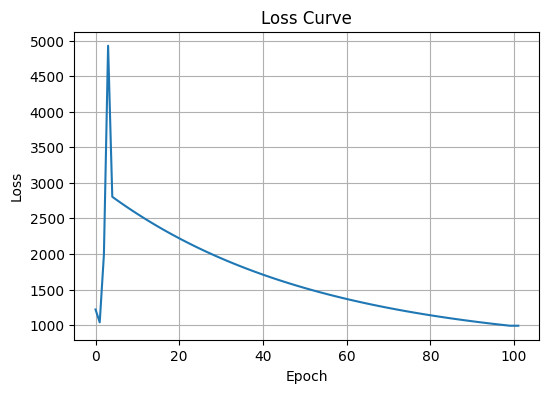

In [ ]:
#Task 12 — Plot the loss curve
import matplotlib.pyplot as plt

# Plot Loss Curve
plt.figure(figsize=(6,4))
plt.plot(loss_history)

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [ ]:
#Task 13 — Test the trained model
# New data
new_hours = np.array([[3], [11], [18]])

# Predict Exam Scores
predicted_scores = forward(new_hours)

print("Predicted Exam Scores:")
print(predicted_scores)

Predicted Exam Scores:
[[28.81980184]
 [28.81980184]
 [28.81980184]]


In [1]:
#Task 14 — Bonus challenge (optional)
learning_rate = 0.01


In [2]:
learning_rate = 0.001

In [3]:
learning_rate = 0.0001